In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math

# loading the required datasets
train_set = np.load('/content/drive/MyDrive/hw2_material/knn/train_set.npy')
train_labels = np.load('/content/drive/MyDrive/hw2_material/knn/train_labels.npy')

test_set = np.load('/content/drive/MyDrive/hw2_material/knn/test_set.npy')
test_labels = np.load('/content/drive/MyDrive/hw2_material/knn/test_labels.npy')

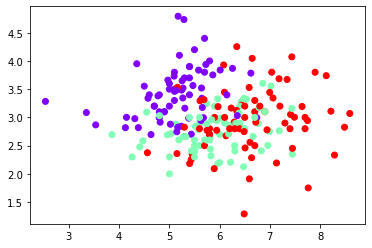

In [ ]:
#taking an initial look at the data
plt.scatter(train_set[:,0],train_set[:,1], c=train_labels, cmap='rainbow')

In [ ]:
def manhattan(point_a, point_b):
    return sum(abs(val1-val2) for val1, val2 in zip(point_a, point_b))

def euclidean(point_a, point_b):
    return np.linalg.norm(point_a - point_b)

def calculate_distances(train_data, test_instance, distance_metric):
    """
    Calculates Manhattan (L1) / Euclidean (L2) distances between test_instance and every train instance.
    :param train_data: An (N, D) shaped numpy array where N is the number of examples
    and D is the dimension of the data.
    :param test_instance: A (D, ) shaped numpy array.
    :param distance_metric: A string which indicates the distance metric, it can be either 'L1' or 'L2'
    :return: An (N, ) shaped numpy array that contains distances.
    """
    result_array = []

    if distance_metric == 'L1':
        for example in train_data:
            result_array.append(manhattan(example, test_instance))
    elif distance_metric == 'L2':
        for example in train_data:
            result_array.append(euclidean(example, test_instance))
    else:
        print("Invalid distance metric!")

    # print("distances list:", result_array)
    return np.array(result_array)

def majority_voting(distances, labels, k):
    """
    Applies majority voting. If there are more then one major class, returns the smallest label.
    :param distances: An (N, ) shaped numpy array that contains distances
    :param labels: An (N, ) shaped numpy array that contains labels
    :param k: An integer. The number of nearest neighbor to be selected.
    :return: An integer. The label of the majority class.
    """

    # create distance-label arrays
    dist_labels = np.array([ np.array([distances[i], labels[i]]) for i in range(len(distances)) ])

    # sort by distance
    dist_labels = dist_labels[np.lexsort(np.fliplr(dist_labels).T)]

    # reduce sorted array to only labels
    dist_labels = dist_labels[:,1:]

    if k == 1:
        return int(dist_labels[0][0])

    # take k closest labels
    dist_labels = dist_labels[0:k,:]

    # flatten array
    dist_labels = list(np.concatenate(dist_labels).flat)
    dist_labels = np.array(dist_labels)

    # get most frequent element
    dist_labels = list(dist_labels)
    dist_labels = [int(x) for x in dist_labels]
    counts = np.bincount(dist_labels)
    retval = np.argmax(counts)
    # group by first column-not used
    # dist_labels = np.split(dist_labels[:,1], np.unique(dist_labels[:, 0], return_index=True)[1][1:])

    # take counts by groups-not used
    # dist_labels = np.array([ np.array([len(dist_labels[i]), i]) for i in range(len(dist_labels)) ])

    return retval

def knn(train_data, train_labels, test_data, test_labels, k, distance_metric):
    """
    Calculates accuracy of knn on test data using train_data.
    :param train_data: An (N, D) shaped numpy array where N is the number of examples
    and D is the dimension of the data
    :param train_labels: An (N, ) shaped numpy array that contains labels
    :param test_data: An (M, D) shaped numpy array where M is the number of examples
    and D is the dimension of the data
    :param test_labels: An (M, ) shaped numpy array that contains labels
    :param k: An integer. The number of nearest neighbor to be selected.
    :param distance_metric: A string which indicates the distance metric, it can be either 'L1' or 'L2'
    :return: A float. The calculated accuracy.
    """
    true_labeling = 0
    i=0
    for test_instance in test_data:
        i+=1
        distances = calculate_distances(train_data, test_instance, distance_metric)
        pred_label = majority_voting(distances, train_labels, k)

        test_i = np.where(test_data == test_instance)
        test_index = test_i[0][0]
        true_label = test_labels[test_index]

        if (pred_label == true_label):
            true_labeling += 1

    accuracy = (true_labeling / i)
    return accuracy

def split_train_and_validation(whole_train_data, whole_train_labels, validation_index, k_fold):
    """
    Splits training dataset into k and returns the validation_indexth one as the
    validation set and others as the training set. You can assume k_fold divides N.
    :param whole_train_data: An (N, D) shaped numpy array where N is the number of examples
    and D is the dimension of the data
    :param whole_train_labels: An (N, ) shaped numpy array that contains labels
    :param validation_index: An integer. 0 <= validation_index < k_fold. Specifies which fold
    will be assigned as validation set.
    :param k_fold: The number of groups that the whole_train_data will be divided into.
    :return: train_data, train_labels, validation_data, validation_labels
    train_data.shape is (N-N/k_fold, D).
    train_labels.shape is (N-N/k_fold, ).
    validation_data.shape is (N/k_fold, D).
    validation_labels.shape is (N/k_fold, ).
    """
    full_size = len(whole_train_labels)
    chunk_size = int(full_size / k_fold)
    start = validation_index * chunk_size
    end = (validation_index + 1) * chunk_size

    val_data, val_labels = whole_train_data[start:end], whole_train_labels[start:end]
    train_data = np.concatenate((whole_train_data[0:start], whole_train_data[end:full_size]))
    train_labels = np.concatenate((whole_train_labels[0:start], whole_train_labels[end:full_size]))

    # print("val data shape:", val_data.shape)
    # print("val labels shape:", val_labels.shape)
    # print("train data shape:", train_data.shape)
    # print("train labels shape:", train_labels.shape)

    return train_data, train_labels, val_data, val_labels

def cross_validation(whole_train_data, whole_train_labels, k_fold, k, distance_metric):
    """
    Applies k_fold cross-validation and averages the calculated accuracies.
    :param whole_train_data: An (N, D) shaped numpy array where N is the number of examples
    and D is the dimension of the data
    :param whole_train_labels: An (N, ) shaped numpy array that contains labels
    :param k_fold: An integer.
    :param k: An integer. The number of nearest neighbor to be selected.
    :param distance_metric: A string which indicates the distance metric, it can be either 'L1' or 'L2'
    :return: A float. Average accuracy calculated.
    """
    # print(" whole train data shape:", whole_train_data.shape)
    # print(" whole train labels shape:", whole_train_labels.shape)
    acc = 0
    for i in range(k_fold):
        train_data, train_labels, val_data, val_labels = split_train_and_validation(whole_train_data, whole_train_labels, i, k_fold)
        acc += knn(train_data, train_labels, val_data, val_labels, k, distance_metric)

    return acc/k_fold


max acc: 0.7681818181818183
max k: 14


Text(0, 0.5, 'Accuracy')

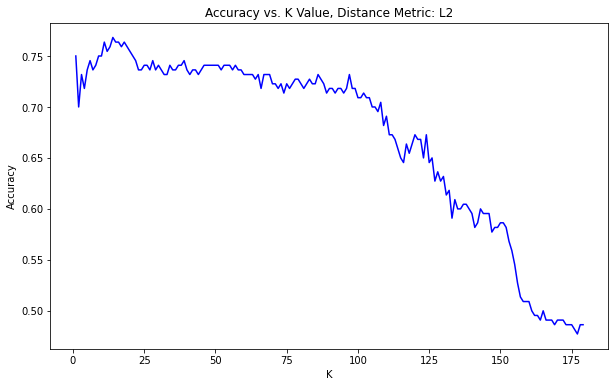

In [ ]:
acc_list = []
k=1
max_acc = 0.1
max_k = 0
while k<180:
    acc = cross_validation(train_set, train_labels, 10, k, "L2")
    if acc > max_acc:
        max_acc = acc
        max_k = k
    acc_list.append(acc)
    # print("acc_list:", acc)
    k+=1



print("max acc:", max_acc)
print("max k:", max_k)

plt.figure(figsize=(10,6))
# plt.plot(range(1,k),acc_list,color='blue', linestyle='dashed', marker='o',
#  markerfacecolor='red', markersize=10)
plt.plot(range(1,k),acc_list,color='blue')
plt.title('Accuracy vs. K Value, Distance Metric: L2')
plt.xlabel('K')
plt.ylabel('Accuracy')

In [ ]:
# print("errors from 80 to 100:", error_rate[80:100])

# test case with k = 13 and distance metric L1
test_acc = cross_validation(test_set, test_labels, 10, 13, "L1")
print("test_acc L1:", test_acc)

# test case with k = 13 and distance metric L1
test_acc = cross_validation(test_set, test_labels, 10, 14, "L2")
print("test_acc L2:", test_acc)

test_acc L1: 0.7500000000000001
test_acc L2: 0.7555555555555555
